In [1]:
from __future__ import print_function, unicode_literals, absolute_import, division
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

from tifffile import imread
from csbdeep.utils import Path, download_and_extract_zip_file, plot_some
from csbdeep.io import save_tiff_imagej_compatible
from csbdeep.models import CARE
import h5py
import os
from lazy5.inspect import get_attrs_dset
import numpy as np
import matplotlib.pyplot as plt
from utils.datagen import create_spend_patches, norm_percentiles,create_spend_dataset_enhanced
from csbdeep.utils import plot_some

I0000 00:00:1773256019.061964    9746 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773256019.498923    9746 cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773256021.093472    9746 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
DATA_FOLDER = "./data/2026/n2n_data/20260213"
filename = "preprocessed_nofilter_myo3_day11_202602131225"
f = h5py.File(os.path.join(DATA_FOLDER,filename + ".h5"), 'r')
# Access the group
preprocessed_group = f['preprocessed_images']

# Print the names of items within the group
print("Items within the 'preprocessed_images' group:")
for key in preprocessed_group.keys():
    print(key)
# Access the 'nofilter_ratio' dataset within the 'preprocessed_images' group
raw_ratio = f['preprocessed_images/nofilter_ratio']

# Print the shape of the extracted dataset
print("Shape of 'nofilter_ratio' dataset:", raw_ratio.shape)
attrs = get_attrs_dset(f, 'preprocessed_images/nofilter_ratio')

Items within the 'preprocessed_images' group:
medfilter_dark
medfilter_nrb_for_ratio
medfilter_ratio
Shape of 'medfilter_ratio' dataset: (186, 500, 2304)


In [22]:
#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe


In [23]:

# Select wn values between 400 and 1800
fast_axis_start = 0
slow_axis_start = 0
ratio = raw_ratio[slow_axis_start:,:,:] # cut off where the stage is not moving
fast_axis_end = fast_axis_start + ratio.shape[1]
wn_mask = (wn >= 400) & (wn <= 1800)
wn_selected = wn[wn_mask]
indices = np.where(wn_mask)[0]
ratio_selected = ratio[:, fast_axis_start:fast_axis_end, indices]
signature_index = 310
point_signal = [90, 70]  # Example point (y, x)
point_noise = [50,25]  # Example point (y, x)s

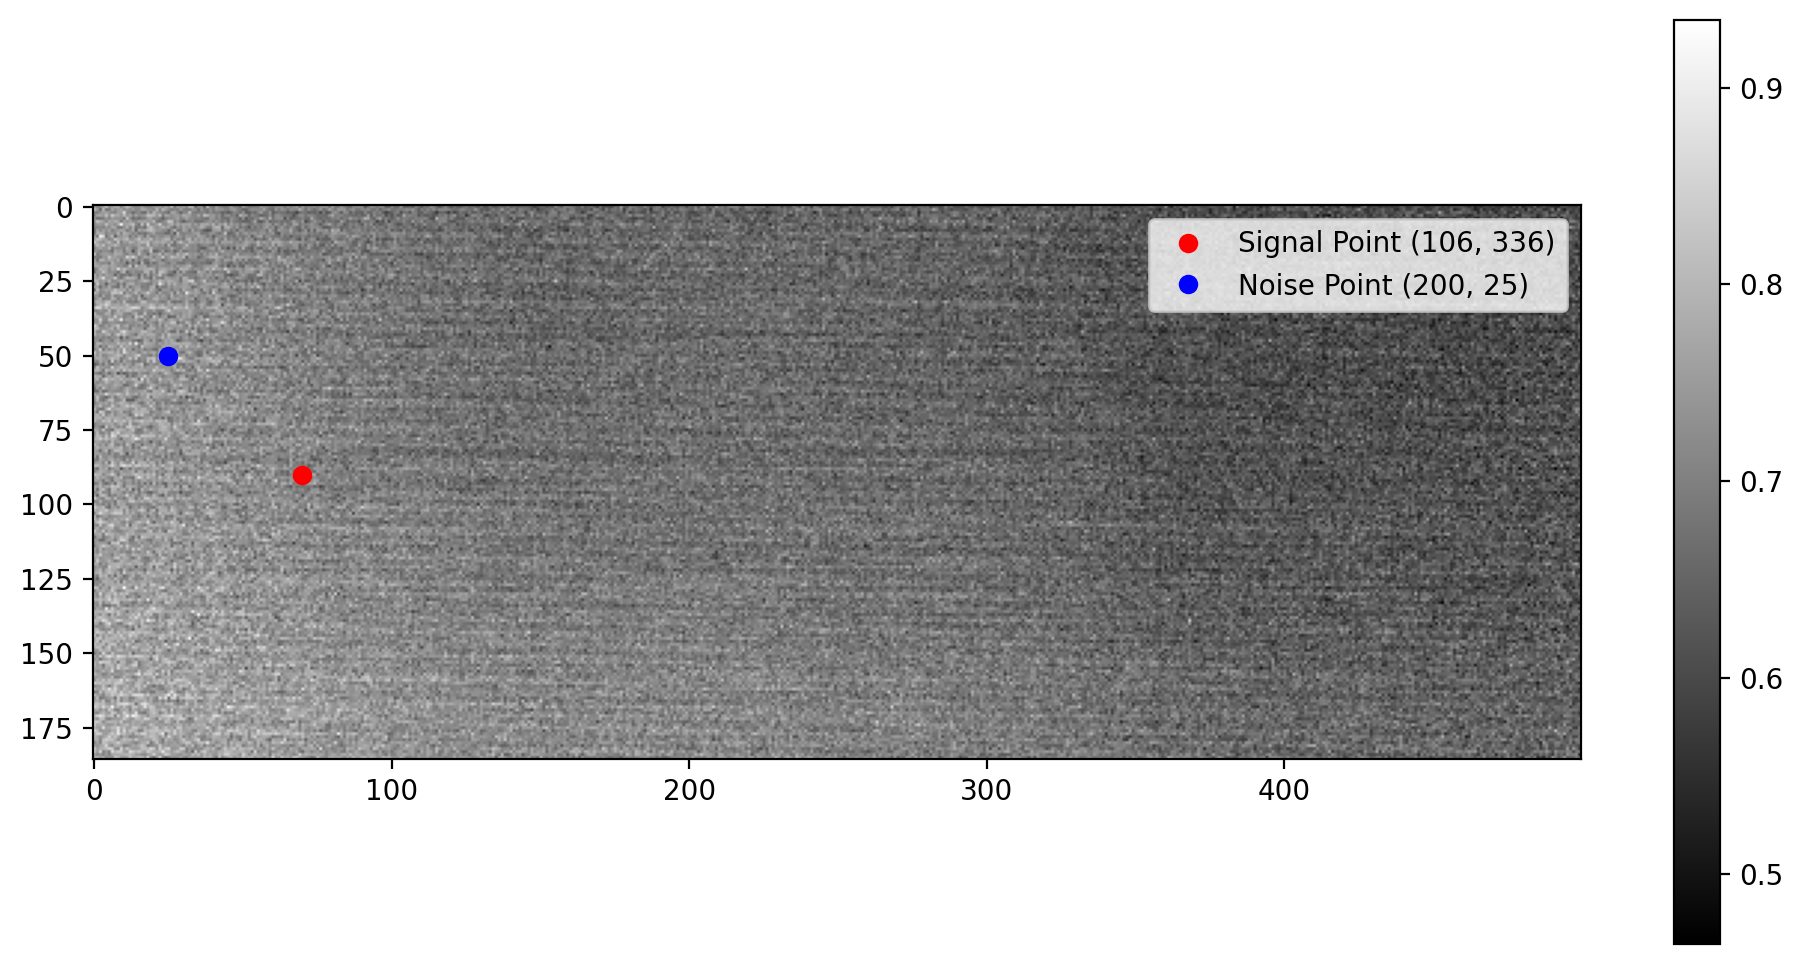

Text(0.5, 1.0, 'Spectra at Selected Points')

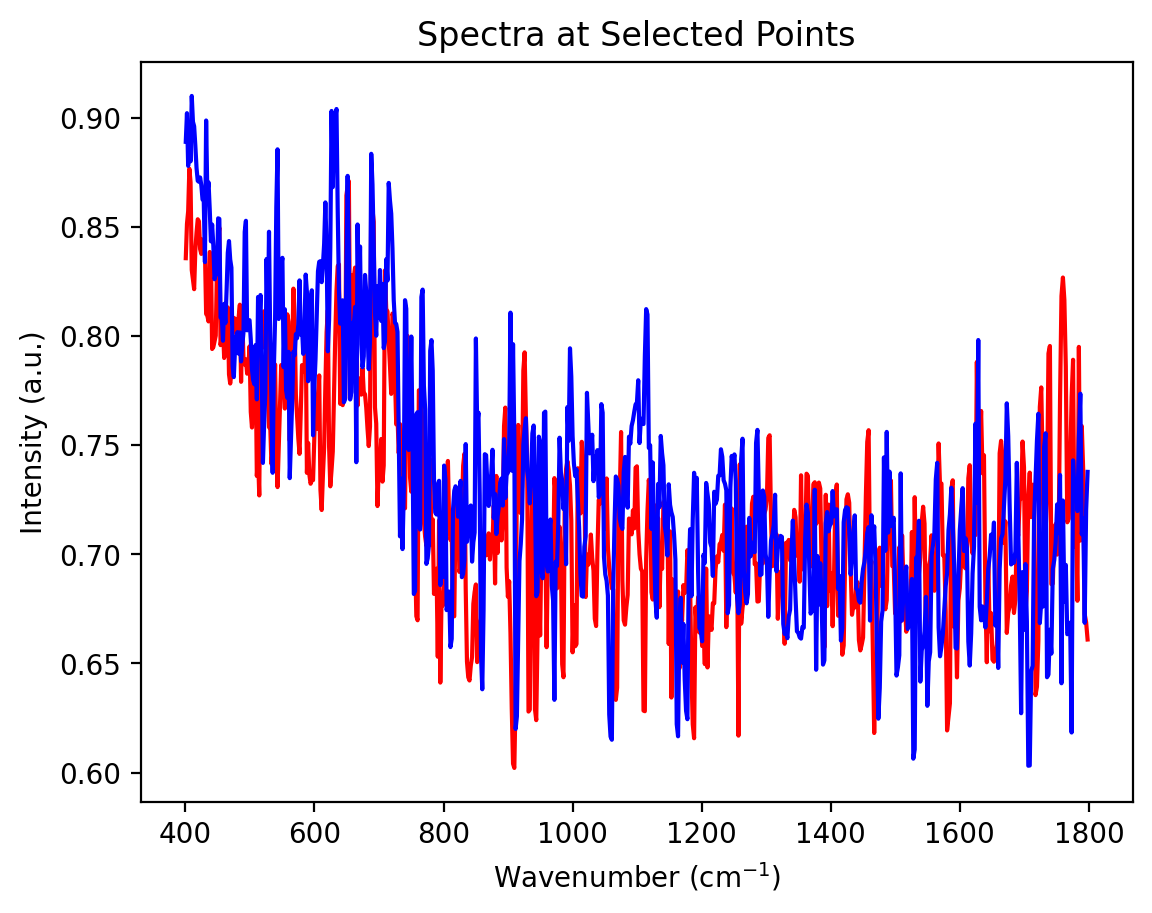

In [24]:
plt.figure(figsize=(12, 6))
plt.imshow(ratio_selected[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()

plt.figure()
plt.plot(wn_selected, ratio_selected[point_signal[0], point_signal[1], :],color="r", label='Signal Point (106, 336)')
plt.plot(wn_selected, ratio_selected[point_noise[0], point_noise[1], :], color="b", label='Noise Point (200, 25)')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Spectra at Selected Points')

In [25]:
print(ratio_selected.shape)
x = ratio_selected.transpose(2,0,1)
axes = 'ZYX'
print(x.shape, axes)

(186, 500, 685)
(685, 186, 500) ZYX


In [26]:
model = CARE(config=None, name='wpermute_model_4layers_20260303_fponly', basedir='models')

Loading network weights from 'weights_best.h5'.


In [27]:
restored = model.predict(x, axes, n_tiles=(16,4,4))

E0000 00:00:1773261746.035207   10599 cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773261746.139218   10599 cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773261750.110057   10599 cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773261750.240069   10599 cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1773261751.324421   10599 cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000

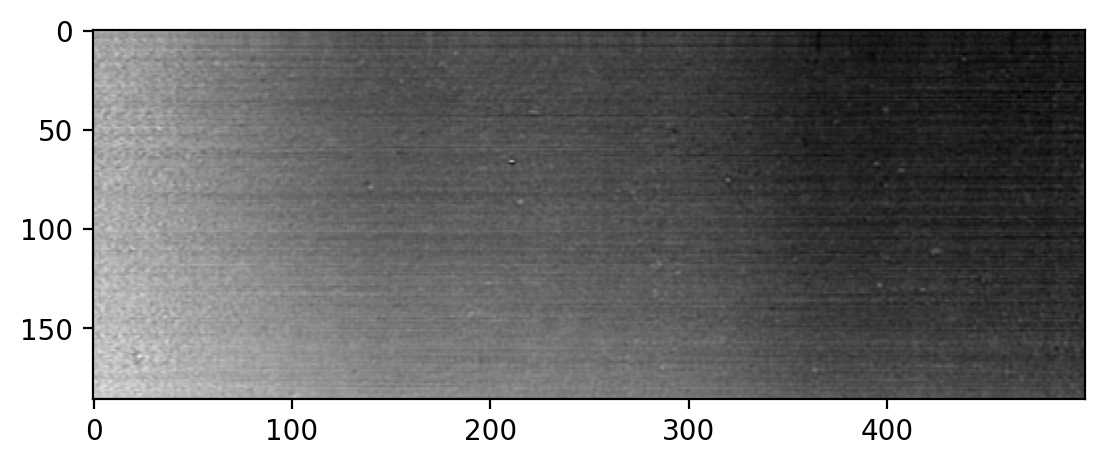

In [32]:
plt.imshow(np.sum(restored, axis=0), cmap='gray')

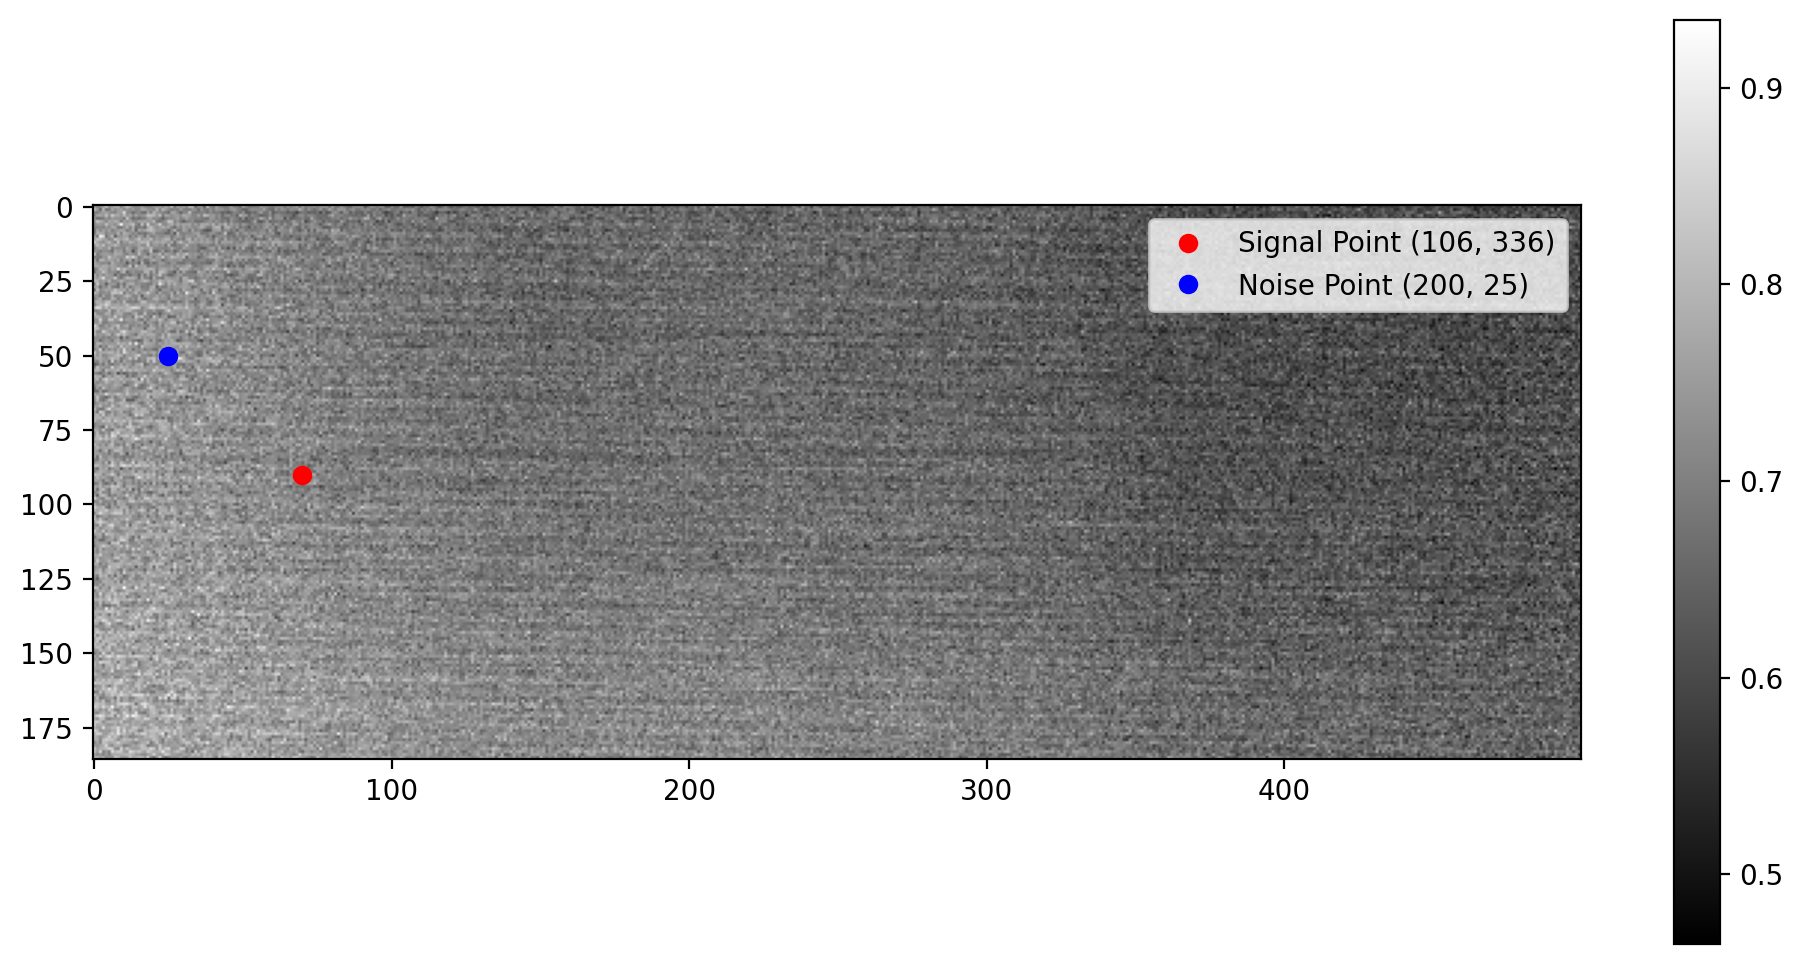

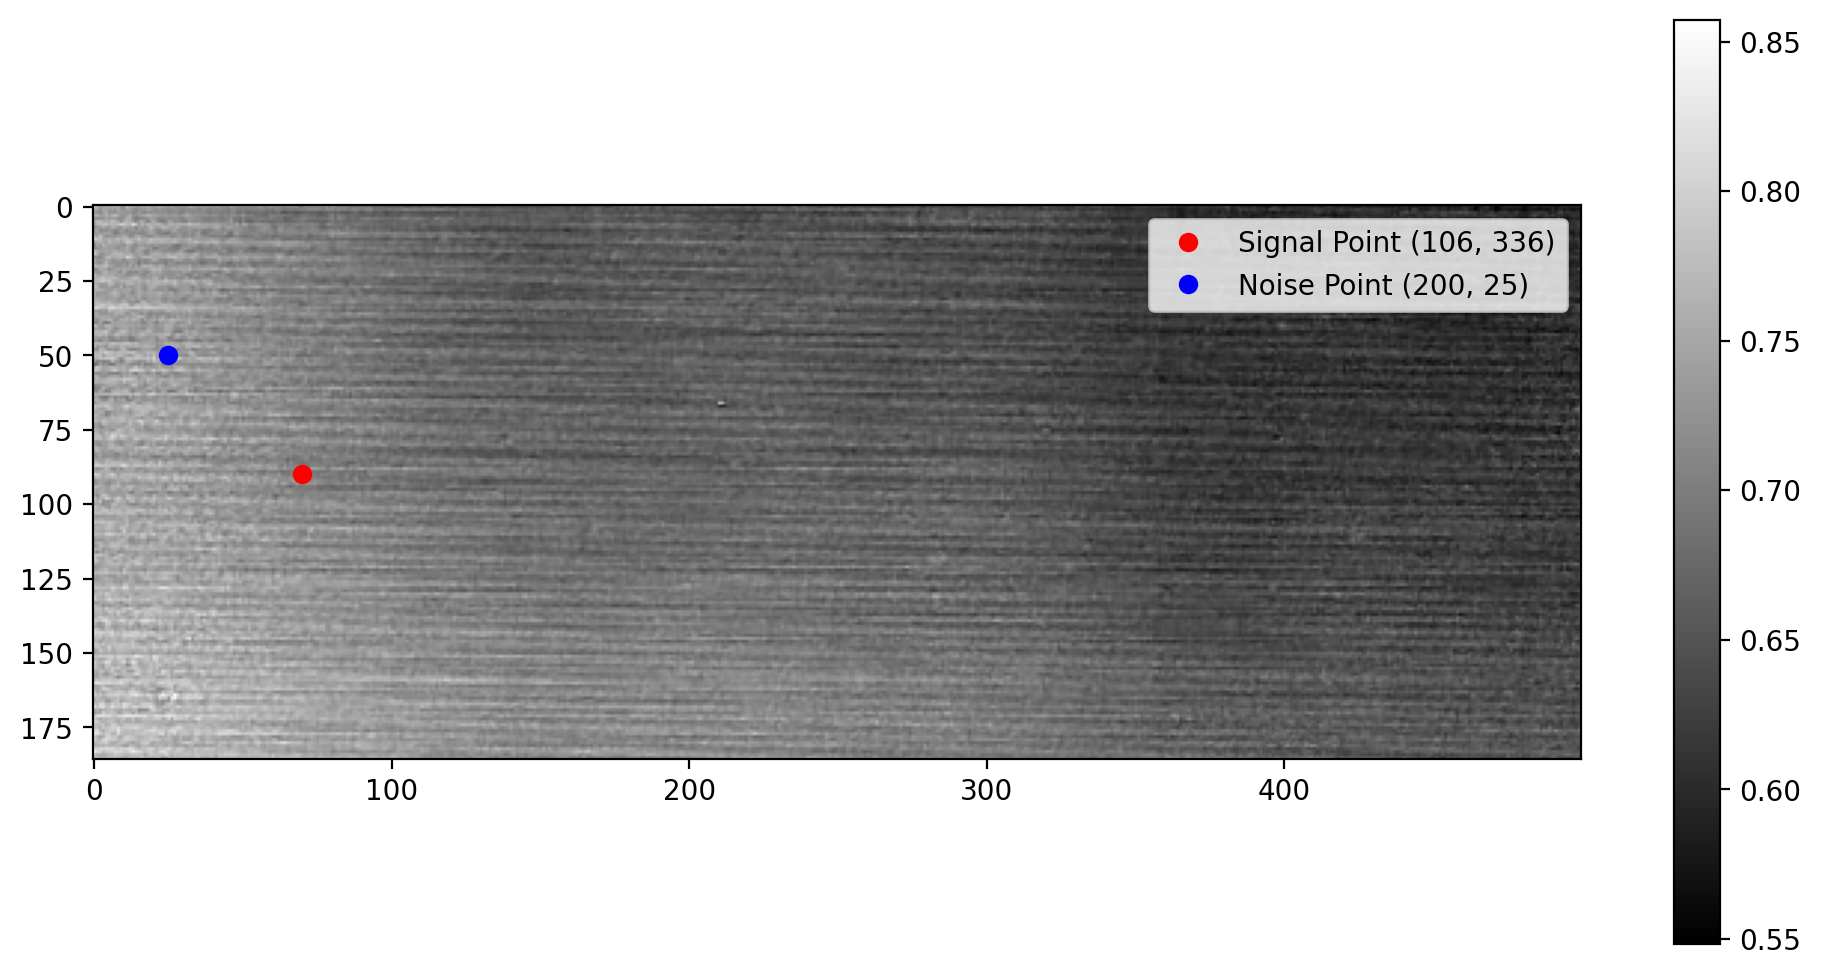

Text(0.5, 1.0, 'Spectra at Selected Points')

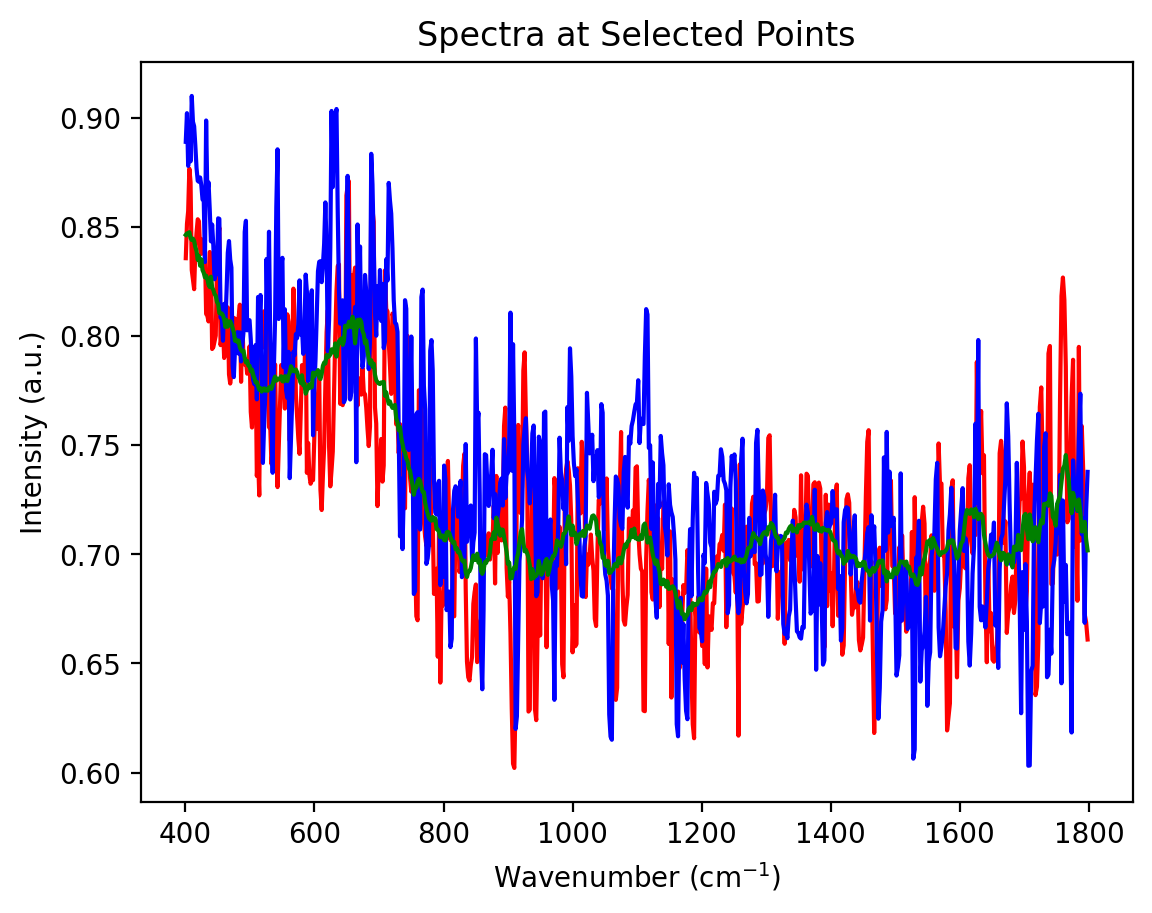

In [29]:
plt.figure(figsize=(12, 6))
plt.imshow(ratio_selected[:,:,signature_index], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()

plt.figure(figsize=(12, 6))
plt.imshow(restored[signature_index,:,:,], cmap='gray')
plt.plot(point_signal[1], point_signal[0], 'ro', label='Signal Point (106, 336)')
plt.plot(point_noise[1], point_noise[0], 'bo', label='Noise Point (200, 25)')
plt.legend()
plt.colorbar()
plt.show()



plt.figure()
plt.plot(wn_selected, ratio_selected[point_signal[0], point_signal[1], :],color="r", label='Signal Point (106, 336)')
plt.plot(wn_selected, ratio_selected[point_noise[0], point_noise[1], :], color="b", label='Noise Point (100, 25)')
plt.plot(wn_selected, restored[:, point_signal[0], point_signal[1]], 'g', label='Restored Signal Point (106, 336)')
plt.xlabel('Wavenumber (cm$^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.title('Spectra at Selected Points')



In [19]:
import tifffile
tifffile.imwrite('restored_image.tiff', restored.astype(np.float32))

In [33]:
np.savez('Results/' + filename + '.npz', raw=ratio_selected, denoised=restored, wn=wn_selected) 

In [19]:
print(wn_selected)

[ 400.61437506  402.46586649  404.31786592  406.17037354  408.02338958
  409.87691423  411.73094772  413.58549025  415.44054202  417.29610325
  419.15217416  421.00875494  422.86584581  424.72344697  426.58155865
  428.44018105  430.29931438  432.15895885  434.01911467  435.87978205
  437.74096121  439.60265235  441.46485569  443.32757144  445.1907998
  447.054541    448.91879524  450.78356274  452.6488437   454.51463834
  456.38094687  458.2477695   460.11510645  461.98295793  463.85132415
  465.72020532  467.58960166  469.45951338  471.3299407   473.20088381
  475.07234295  476.94431832  478.81681014  480.68981862  482.56334397
  484.43738642  486.31194616  488.18702342  490.06261841  491.93873135
  493.81536244  495.69251192  497.57017998  499.44836684  501.32707273
  503.20629785  505.08604242  506.96630665  508.84709077  510.72839498
  512.61021951  514.49256456  516.37543036  518.25881711  520.14272505
  522.02715437  523.91210531  525.79757807  527.68357288  529.57008994
  531.4